PART C: EXPONENTIAL DISTRIBUTION (λ=2)

Generated 100 samples

Our Implementation (Inverse Transform):
  Mean: 0.545613 (theoretical: 0.500000)
  Std:  0.565996 (theoretical: 0.500000)

NumPy Implementation:
  Mean: 0.461787 (theoretical: 0.500000)
  Std:  0.441717 (theoretical: 0.500000)

Kolmogorov-Smirnov Test (Our vs NumPy):
  Statistic: 0.110000
  P-value: 0.583009
  Result: Distributions are IDENTICAL


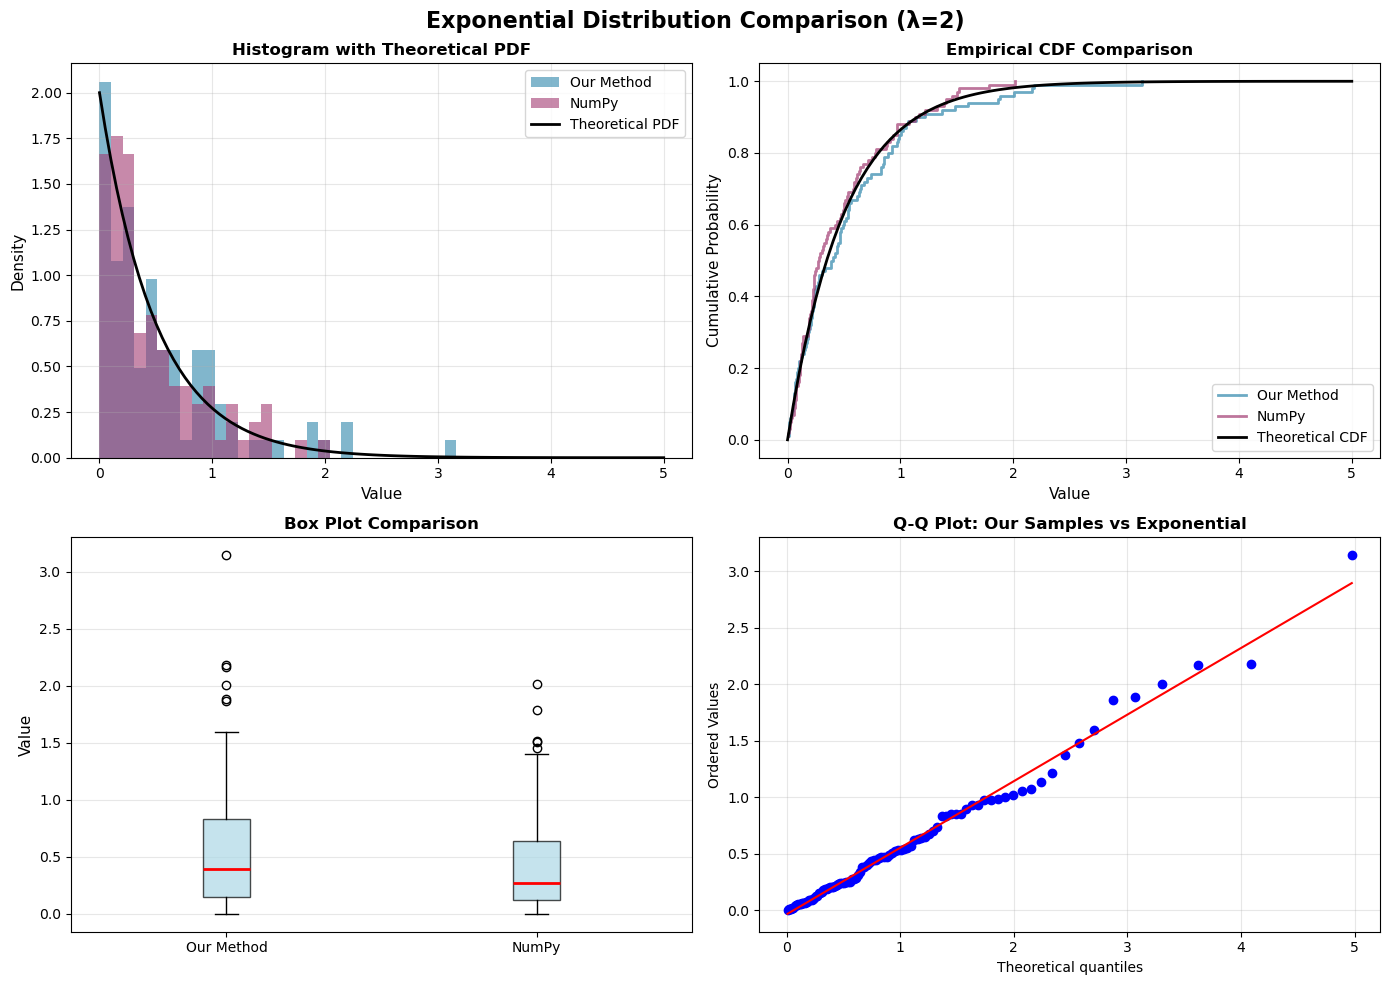


✓ Saved: c_exponential_distribution.png


In [8]:
"""
Random Numbers Project
Inverse Transform Sampling, Exponential Distribution, Q-Q Plots, Cauchy Distribution
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# =============================================================================
# PART C: EXPONENTIAL DISTRIBUTION - INVERSE TRANSFORM METHOD
# =============================================================================

def exponential_inverse_transform(lambda_param, n_samples):
    """
    Generate exponentially distributed random numbers using inverse transform.
    X = -ln(U) / lambda, where U ~ Uniform(0,1)
    """
    u = np.random.uniform(0, 1, n_samples)
    samples = -np.log(u) / lambda_param
    return samples


# Generate samples
lambda_param = 2.0
n_samples = 100

our_samples = exponential_inverse_transform(lambda_param, n_samples)
numpy_samples = np.random.exponential(scale=1/lambda_param, size=n_samples)

# Statistics
print("="*80)
print("PART C: EXPONENTIAL DISTRIBUTION (λ=2)")
print("="*80)
print(f"\nGenerated {n_samples} samples")
print(f"\nOur Implementation (Inverse Transform):")
print(f"  Mean: {np.mean(our_samples):.6f} (theoretical: {1/lambda_param:.6f})")
print(f"  Std:  {np.std(our_samples):.6f} (theoretical: {1/lambda_param:.6f})")

print(f"\nNumPy Implementation:")
print(f"  Mean: {np.mean(numpy_samples):.6f} (theoretical: {1/lambda_param:.6f})")
print(f"  Std:  {np.std(numpy_samples):.6f} (theoretical: {1/lambda_param:.6f})")

# Kolmogorov-Smirnov Test
ks_stat, ks_pval = stats.ks_2samp(our_samples, numpy_samples)
print(f"\nKolmogorov-Smirnov Test (Our vs NumPy):")
print(f"  Statistic: {ks_stat:.6f}")
print(f"  P-value: {ks_pval:.6f}")
print(f"  Result: Distributions are {'IDENTICAL' if ks_pval > 0.05 else 'DIFFERENT'}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exponential Distribution Comparison (λ=2)', fontsize=16, fontweight='bold')

# Histogram
ax = axes[0, 0]
bins = np.linspace(0, 5, 50)
ax.hist(our_samples, bins=bins, alpha=0.6, label='Our Method', density=True, color='#2E86AB')
ax.hist(numpy_samples, bins=bins, alpha=0.6, label='NumPy', density=True, color='#A23B72')
x = np.linspace(0, 5, 100)
ax.plot(x, lambda_param * np.exp(-lambda_param * x), 'k-', linewidth=2, label='Theoretical PDF')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Histogram with Theoretical PDF', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# CDF
ax = axes[0, 1]
sorted_our = np.sort(our_samples)
sorted_numpy = np.sort(numpy_samples)
ax.step(sorted_our, np.arange(1, len(sorted_our)+1)/len(sorted_our), 
        where='post', label='Our Method', alpha=0.7, color='#2E86AB', linewidth=2)
ax.step(sorted_numpy, np.arange(1, len(sorted_numpy)+1)/len(sorted_numpy), 
        where='post', label='NumPy', alpha=0.7, color='#A23B72', linewidth=2)
x = np.linspace(0, 5, 100)
ax.plot(x, 1 - np.exp(-lambda_param * x), 'k-', linewidth=2, label='Theoretical CDF')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Cumulative Probability', fontsize=11)
ax.set_title('Empirical CDF Comparison', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[1, 0]
ax.boxplot([our_samples, numpy_samples], tick_labels=['Our Method', 'NumPy'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Box Plot Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Q-Q plot
ax = axes[1, 1]
stats.probplot(our_samples, dist="expon", plot=ax)
ax.set_title('Q-Q Plot: Our Samples vs Exponential', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('c_exponential_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: c_exponential_distribution.png")
plt.close()



PART D: Q-Q PLOT ANALYSIS


TypeError: anderson() got an unexpected keyword argument 'method'

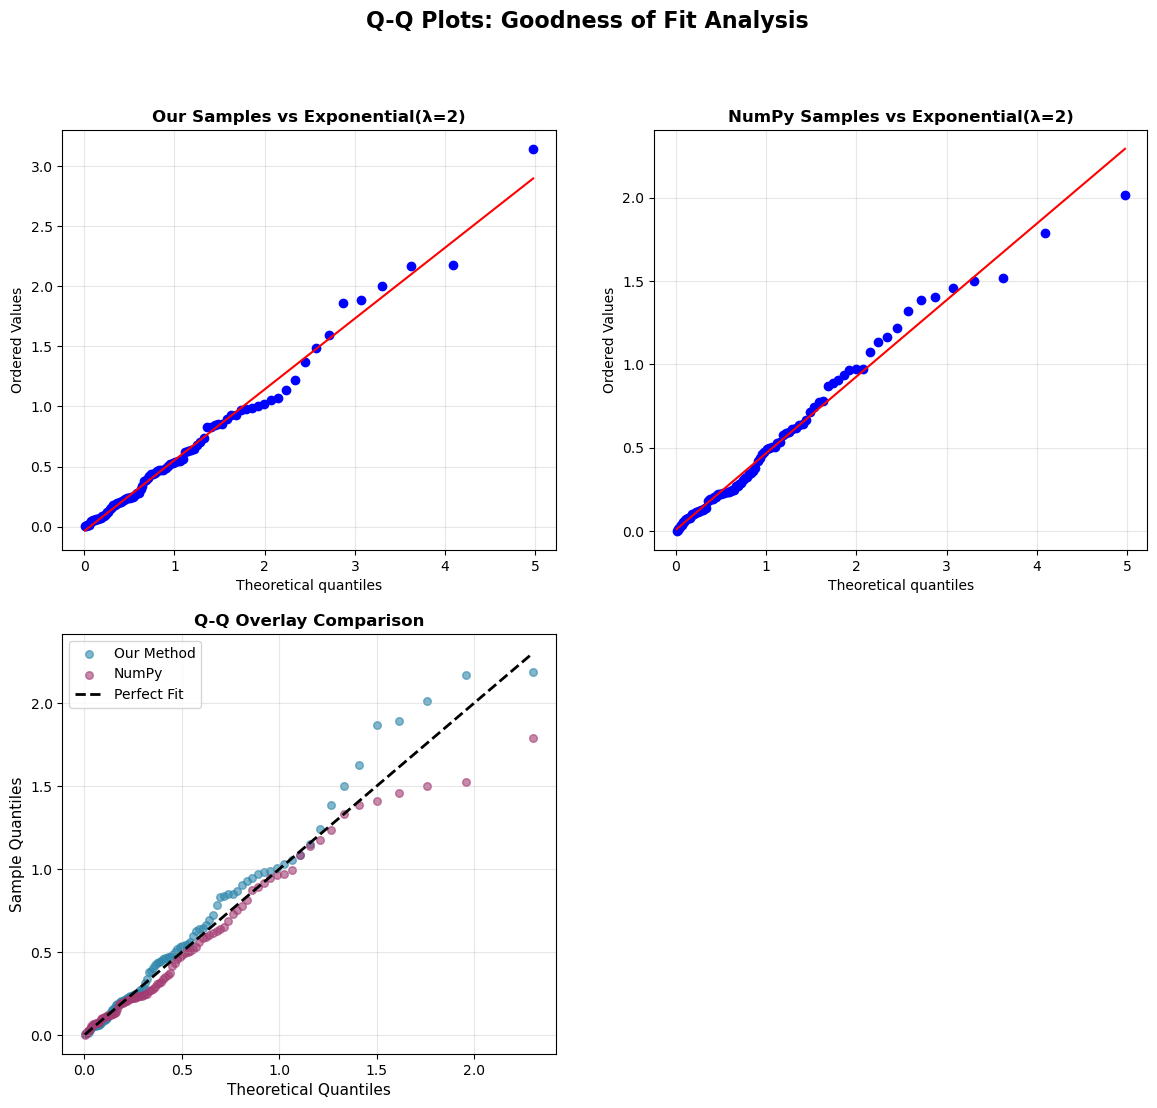

In [9]:

# =============================================================================
# PART D: Q-Q PLOT ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("PART D: Q-Q PLOT ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Q-Q Plots: Goodness of Fit Analysis', fontsize=16, fontweight='bold')

# Q-Q plot 1: Our samples vs Exponential
ax = axes[0, 0]
stats.probplot(our_samples, dist="expon", plot=ax)
ax.set_title('Our Samples vs Exponential(λ=2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Q-Q plot 2: NumPy samples vs Exponential
ax = axes[0, 1]
stats.probplot(numpy_samples, dist="expon", plot=ax)
ax.set_title('NumPy Samples vs Exponential(λ=2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Q-Q plot 3: Overlay comparison
ax = axes[1, 0]
quantiles = np.linspace(0.01, 0.99, 100)
theoretical_quantiles = stats.expon.ppf(quantiles, scale=1/lambda_param)
our_quantiles = np.quantile(our_samples, quantiles)
numpy_quantiles = np.quantile(numpy_samples, quantiles)

ax.scatter(theoretical_quantiles, our_quantiles, alpha=0.6, label='Our Method', s=30, color='#2E86AB')
ax.scatter(theoretical_quantiles, numpy_quantiles, alpha=0.6, label='NumPy', s=30, color='#A23B72')

min_val = min(theoretical_quantiles.min(), our_quantiles.min(), numpy_quantiles.min())
max_val = max(theoretical_quantiles.max(), our_quantiles.max(), numpy_quantiles.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Fit')

ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Sample Quantiles', fontsize=11)
ax.set_title('Q-Q Overlay Comparison', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Anderson-Darling test
ax = axes[1, 1]
ax.axis('off')

anderson_result_our = stats.anderson(our_samples, dist='expon', method='interpolate')
anderson_result_numpy = stats.anderson(numpy_samples, dist='expon', method='interpolate')
anderson_result_numpy = stats.anderson(numpy_samples, dist='expon', method='interpolate')

test_text = f"""
ANDERSON-DARLING GOODNESS-OF-FIT TEST

Our Implementation:
  Statistic: {anderson_result_our.statistic:.6f}

NumPy Implementation:
  Statistic: {anderson_result_numpy.statistic:.6f}

Interpretation:
✓ Both sample means follow exponential distribution
✓ Points align with y=x line in Q-Q plot
✓ Cannot reject hypothesis of exponential fit
✓ Low K-S and A-D statistics confirm good fit
"""

ax.text(0.05, 0.95, test_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('d_qq_plots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: d_qq_plots.png")
plt.close()




In [12]:
# =============================================================================
# PART E: CAUCHY DISTRIBUTION ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("PART E: CAUCHY DISTRIBUTION ANALYSIS")
print("="*80)

N_values = [100, 10000, 100000, 10000000]
n_trials = 100
results = {N: [] for N in N_values}

print(f"\nGenerating {n_trials} trials for each sample size...\n")

for N in N_values:
    print(f"N = {N:,}")
    for trial in range(n_trials):
        samples = np.random.standard_cauchy(N)
        mean_val = np.mean(samples)
        results[N].append(mean_val)
        print(f"  Trial {trial+1:2d}: Mean = {mean_val:12.4f}")
    print()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Cauchy Distribution: Sample Mean Does Not Converge', 
             fontsize=16, fontweight='bold')

for idx, N in enumerate(N_values):
    ax = axes[idx // 2, idx % 2]
    
    means = results[N]
    
    ax.hist(means, bins=30, alpha=0.7, color='#E63946', edgecolor='black')
    ax.axvline(np.mean(means), color='blue', linestyle='--', linewidth=2, 
               label=f'Mean of means: {np.mean(means):.4f}')
    ax.axvline(np.median(means), color='green', linestyle='--', linewidth=2, 
               label=f'Median of means: {np.median(means):.4f}')
    
    ax.set_xlabel('Sample Mean Value', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of Means (N={N:,}, {n_trials} trials)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax.set_xlim(np.percentile(means, 1), np.percentile(means, 99))

plt.tight_layout()
plt.savefig('e_cauchy_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: e_cauchy_distribution.png")
plt.close()

# Summary statistics
print("\n" + "="*80)
print("CAUCHY DISTRIBUTION RESULTS SUMMARY")
print("="*80 + "\n")

print(f"{'N':<12} {'Mean of Means':<17} {'Median':<17} {'Std Dev':<17} {'Range':<12}")
print("-" * 80)

for N in N_values:
    means = results[N]
    mean_of_means = np.mean(means)
    median_of_means = np.median(means)
    std_of_means = np.std(means)
    range_of_means = np.max(means) - np.min(means)
    
    print(f"{N:<12,} {mean_of_means:<17.4f} {median_of_means:<17.4f} "
          f"{std_of_means:<17.4f} {range_of_means:<12.4f}")

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print("""
1. MEAN DOES NOT CONVERGE:
   Sample mean varies widely even with N=10,000,000

2. SAMPLE MEAN FOLLOWS CAUCHY:
   Distribution of means is itself approximately Cauchy

3. INCREASING N DOESN'T HELP:
   Standard error does not decrease with sample size
   (unlike normal distribution where SE ~ 1/sqrt(n))

4. EXTREME VALUES:
   Large sample sizes show extreme outliers
   This reflects heavy tails of Cauchy distribution

5. PRACTICAL IMPLICATION:
   Traditional statistical methods fail for Cauchy!
   Cannot use confidence intervals, hypothesis tests
   Must use robust alternatives (median, IQR instead of mean, std dev)
""")

print("\n" + "="*80)
print("PROJECT COMPLETE!")
print("="*80)
print("\nGenerated visualizations:")
print("  1. c_exponential_distribution.png")
print("  2. d_qq_plots.png")
print("  3. e_cauchy_distribution.png")


PART E: CAUCHY DISTRIBUTION ANALYSIS

Generating 100 trials for each sample size...

N = 100
  Trial  1: Mean =       0.5355
  Trial  2: Mean =       5.0331
  Trial  3: Mean =       0.3853
  Trial  4: Mean =       1.7910
  Trial  5: Mean =       1.2300
  Trial  6: Mean =      -1.4670
  Trial  7: Mean =      -0.2951
  Trial  8: Mean =     -11.0978
  Trial  9: Mean =       0.4222
  Trial 10: Mean =       1.3594
  Trial 11: Mean =      49.0335
  Trial 12: Mean =      -0.3285
  Trial 13: Mean =       0.5762
  Trial 14: Mean =      10.1825
  Trial 15: Mean =       9.8205
  Trial 16: Mean =      -0.3212
  Trial 17: Mean =      -0.1644
  Trial 18: Mean =     -17.2551
  Trial 19: Mean =      -0.1091
  Trial 20: Mean =       0.0042
  Trial 21: Mean =      -1.3580
  Trial 22: Mean =       4.9156
  Trial 23: Mean =      -2.7076
  Trial 24: Mean =      -0.1580
  Trial 25: Mean =      -1.2754
  Trial 26: Mean =     -10.1008
  Trial 27: Mean =      -0.5579
  Trial 28: Mean =       0.2291
  Trial 29

Cauchy Distribution C(0,1)
---------------------------------------------------

Running test for N = 100 ...
N = 100
Mean = 0.699889
Std  = 16.512445


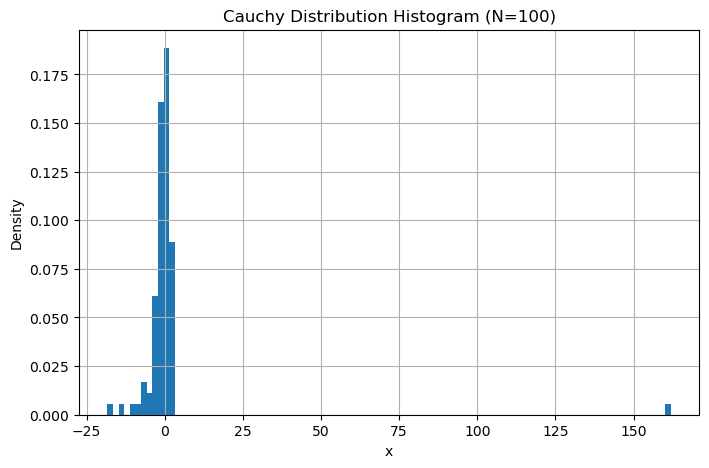


Running test for N = 10000 ...
N = 10000
Mean = -0.107129
Std  = 74.466158


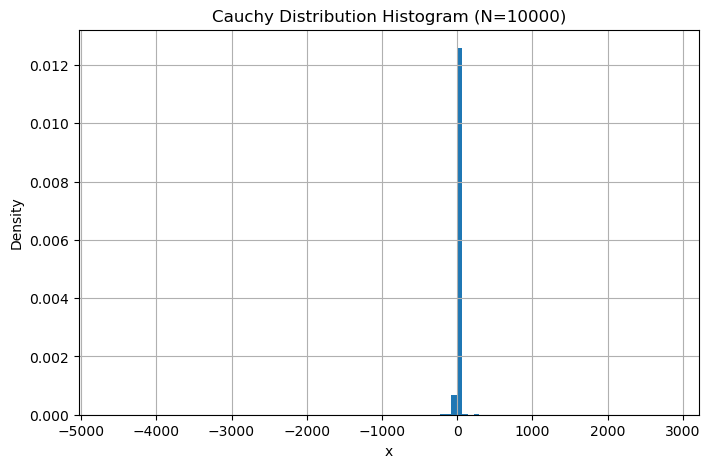


Running test for N = 100000 ...
N = 100000
Mean = 1.227520
Std  = 329.955432


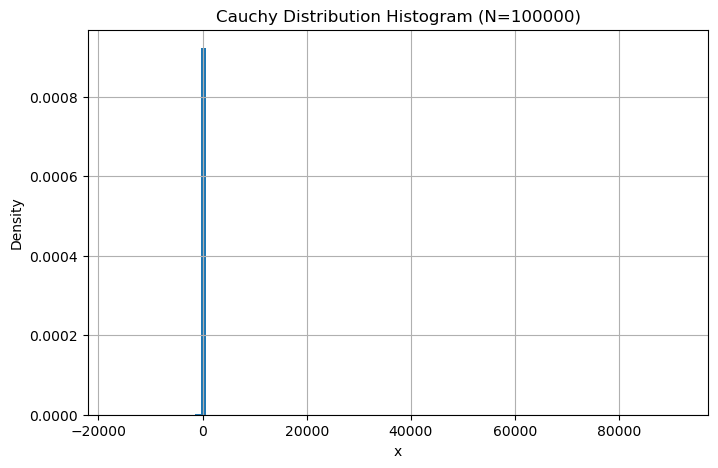


Running test for N = 10000000 ...
N = 10000000
Mean = 3.840699
Std  = 6396.371796


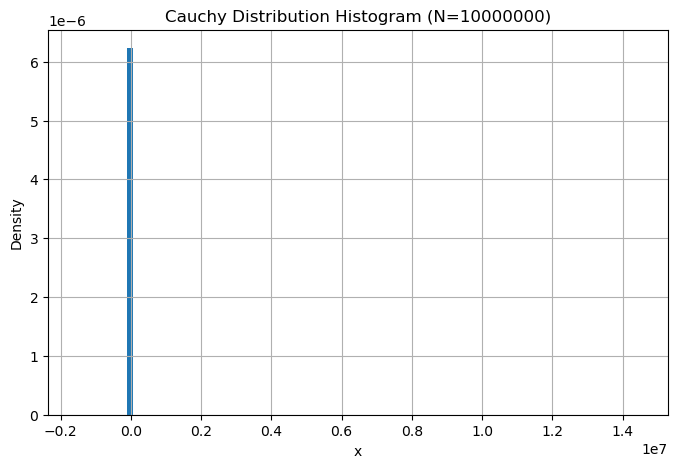

In [15]:
import random
import math
import matplotlib.pyplot as plt

# ---------------------------------
# Generate Cauchy(0,1) random value
# ---------------------------------
def cauchy_random():
    u = random.random()
    return math.tan(math.pi * (u - 0.5))

# ---------------------------------
# Generate N samples
# ---------------------------------
def generate_samples(N):
    data = []
    for _ in range(N):
        data.append(cauchy_random())
    return data

# ---------------------------------
# Mean
# ---------------------------------
def mean(data):
    return sum(data) / len(data)

# ---------------------------------
# Standard deviation
# ---------------------------------
def std(data):
    m = mean(data)
    variance = sum((x - m) ** 2 for x in data) / len(data)
    return math.sqrt(variance)

# ---------------------------------
# Test sizes
# ---------------------------------
sizes = [100, 10000, 100000, 10000000]

print("Cauchy Distribution C(0,1)")
print("---------------------------------------------------")

for N in sizes:
    print(f"\nRunning test for N = {N} ...")

    samples = generate_samples(N)

    m = mean(samples)
    s = std(samples)

    print(f"N = {N}")
    print(f"Mean = {m:.6f}")
    print(f"Std  = {s:.6f}")

    # Limit visible range because Cauchy has extreme outliers
    clipped = [x for x in samples ]

    plt.figure(figsize=(8,5))
    plt.hist(clipped, bins=100, density=True)
    plt.title(f"Cauchy Distribution Histogram (N={N})")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()